# Iris- Tpot

### Importar bibliotecas

In [14]:
from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\stopit\__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Carregar Dados

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Análise Exploratória

In [7]:
print("Dimensão:", df.shape)

print("\nDistribuição das classes:")
print(df["target"].value_counts())

print("\nResumo estatístico:")
df.describe()

Dimensão: (150, 5)

Distribuição das classes:
target
0    50
1    50
2    50
Name: count, dtype: int64

Resumo estatístico:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Distribuição das Classes

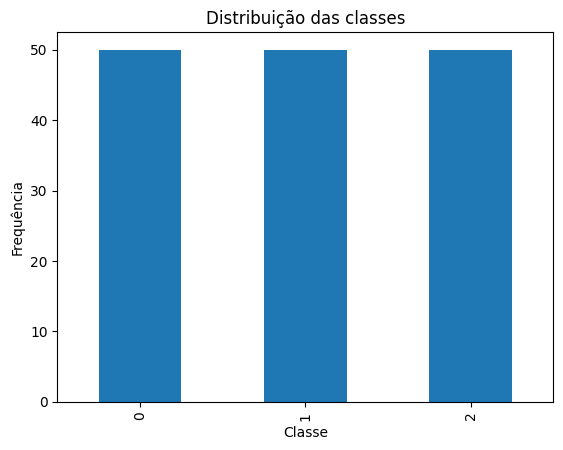

In [8]:
df["target"].value_counts().plot(kind="bar")

plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Frequência")

plt.show()

O dataset apresenta uma distribuição equilibrada entre as classes, o que permite uma avaliação justa dos modelos sem necessidade de técnicas de balanceamento.

### Distribuição das Variáveis

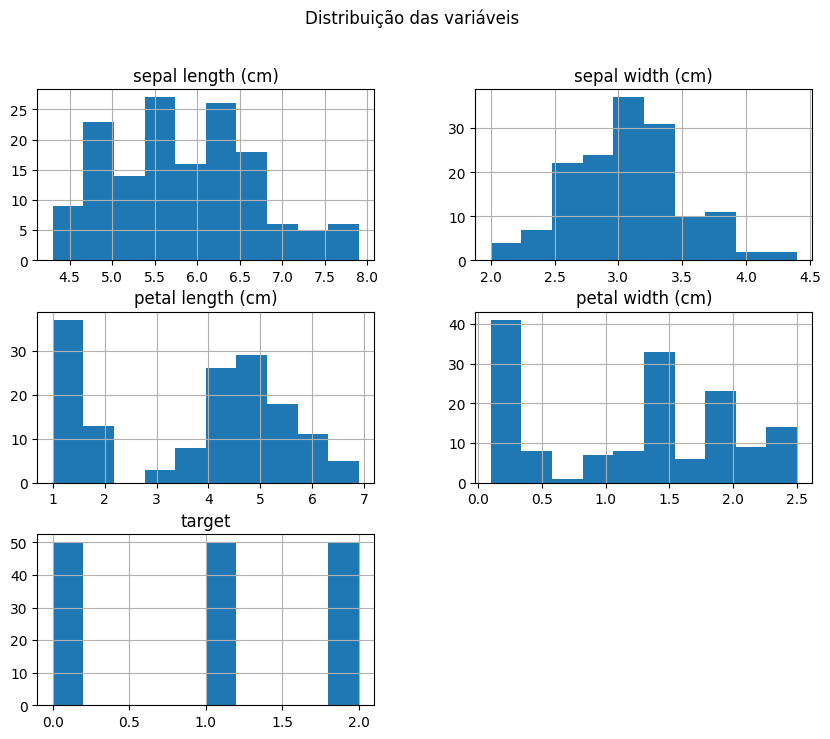

In [10]:
df.hist(figsize=(10,8))
plt.suptitle("Distribuição das variáveis")

plt.show()

A distribuição das variáveis evidencia padrões distintos, destacando-se as variáveis petal_length e petal_width pela sua maior capacidade de separação entre classes, ao contrário das variáveis sepal, que apresentam maior sobreposição e menor poder discriminativo

### Relação entre Variáveis

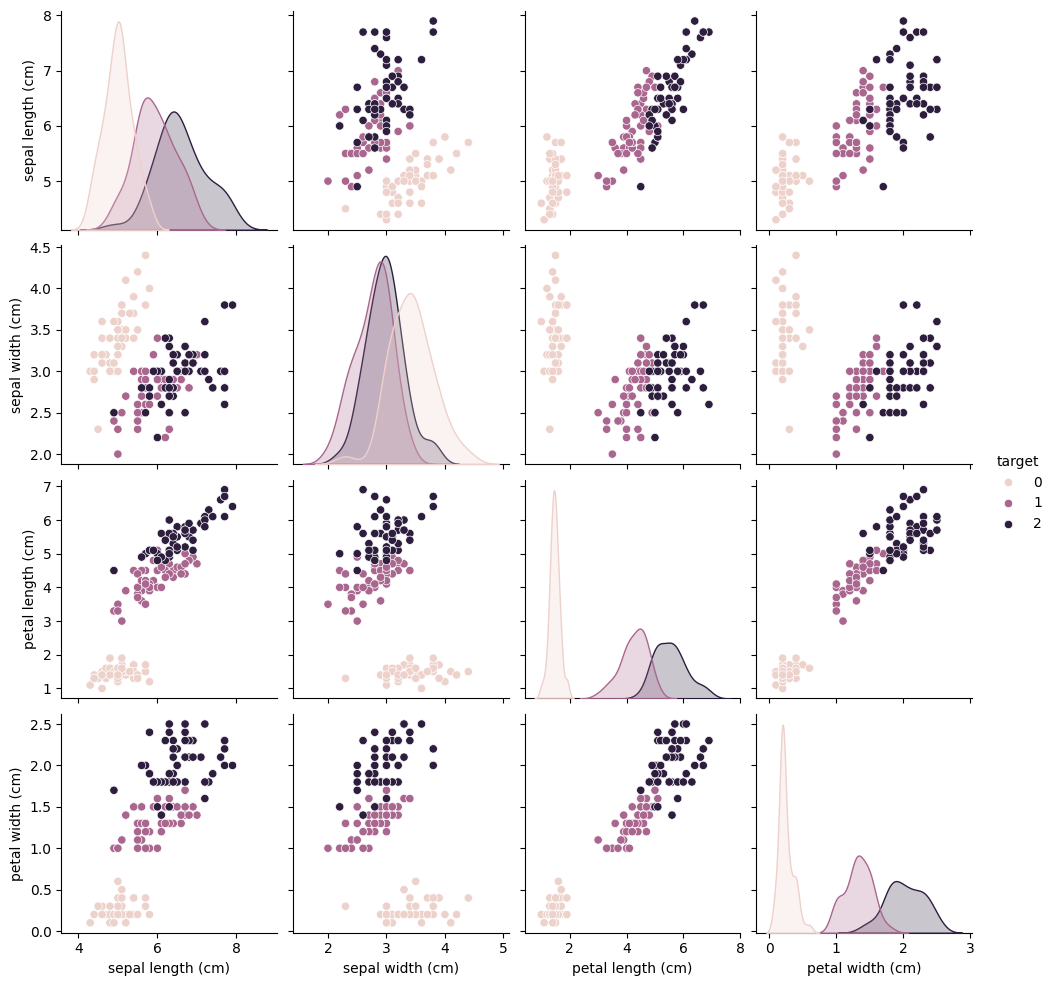

In [11]:
sns.pairplot(df, hue="target")

plt.show()

Observa-se uma separação clara entre classes, especialmente nas variáveis petal length e petal width, indicando que o problema é altamente separável.

### Matriz de Correlação

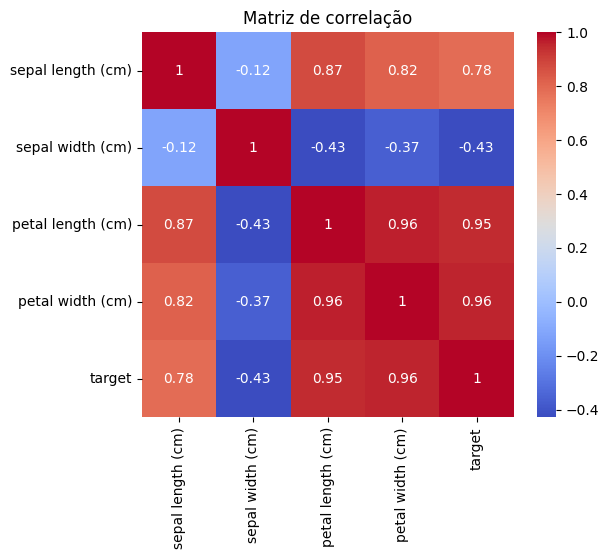

In [12]:
corr = df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de correlação")
plt.show()

A matriz de correlação evidencia uma forte relação positiva entre petal_length e petal_width, indicando elevada redundância de informação, enquanto sepal_width apresenta correlações fracas ou negativas com as restantes variáveis, revelando menor relevância para a distinção entre classes.

## Conclusão da Análise Exploratória

- O dataset apresenta classes perfeitamente equilibradas.
- As variáveis das pétalas evidenciam maior capacidade discriminativa.
- Existe uma separação clara entre as classes, facilitando a tarefa de classificação.
- Algumas variáveis apresentam forte correlação, indicando possível redundância, mas também elevado poder explicativo.
- Trata-se de um dataset simples, bem estruturado e com baixo nível de ruído.

Estas características ajudam a explicar o elevado desempenho obtido pelos modelos de AutoML, incluindo o TPOT.

Adicionalmente, a simplicidade do dataset reduz a complexidade do espaço de procura explorado pelo TPOT, contribuindo para a rápida identificação de soluções com desempenho elevado.

### Definir Váriaveis Explicativas e Alvo

In [16]:
X = df.drop("target", axis=1)
y = df["target"]

print("Variáveis explicativas:", X.columns.tolist())
print("Variável alvo: target")

Variáveis explicativas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Variável alvo: target


### Dividir em Treino e Teste

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


## Criar e Treinar o Tpot

In [18]:
tpot = TPOTClassifier(
    generations=3,
    population_size=10,
    verbose=2,
    random_state=42,
    n_jobs=1
)

tpot.fit(X_train, y_train)

C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\tpot\tpot_estimator\estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
Generation: 100%|██████████| 3/3 [01:15<00:00, 25.22s/it]


,search_space,<tpot.search_...00156C0554A70>
,scorers,['roc_auc_ovr']
,scorers_weights,[1]
,cv,10
,other_objective_functions,[]
,other_objective_functions_weights,[]
,objective_function_names,None
,bigger_is_better,True
,categorical_features,None
,memory,None
,preprocessing,False


### Identificar os 3 Melhores Modelos/Pipeline

In [35]:
# Copiar os pipelines avaliados
df_tpot = tpot.evaluated_individuals.copy()

# Remover pipelines inválidos
df_validos = df_tpot[df_tpot["Eval Error"].isna()].copy()

# Ordenar pelos melhores scores
df_top3 = df_validos.sort_values(by="roc_auc_score", ascending=False).head(3)

print("=== 3 melhores pipelines avaliados pelo TPOT ===")
print(df_top3[["roc_auc_score", "Generation", "Variation_Function", "Instance"]])

=== 3 melhores pipelines avaliados pelo TPOT ===
    roc_auc_score  Generation Variation_Function  \
11            1.0         1.0         ind_mutate   
7             1.0         0.0                NaN   
15            1.0         1.0         ind_mutate   

                                             Instance  
11  (StandardScaler(), VarianceThreshold(threshold...  
7   (StandardScaler(), SelectPercentile(percentile...  
15  (MaxAbsScaler(), SelectPercentile(percentile=3...  


### Mostrar de Forma Mais Limpa Quais São

In [36]:
print("=== Identificação dos 3 melhores pipelines ===\n")

for i, (_, row) in enumerate(df_top3.iterrows(), start=1):
    print(f"Pipeline {i}")
    print(f"Score: {row['roc_auc_score']}")
    print(f"Geração: {row['Generation']}")
    print(f"Função de variação: {row['Variation_Function']}")
    print(f"Pipeline: {row['Instance']}")
    print("-" * 80)

=== Identificação dos 3 melhores pipelines ===

Pipeline 1
Score: 1.0
Geração: 1.0
Função de variação: ind_mutate
Pipeline: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('variancethreshold',
                 VarianceThreshold(threshold=0.0031917008133)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('gaussiannb', GaussianNB())])
-----------------------------------------------------------------

### Análise Automática dos 3 Melhores Pipelines

In [37]:
print("=== Análise automática dos 3 melhores pipelines do TPOT ===\n")

for i, (_, row) in enumerate(df_top3.iterrows(), start=1):
    score = row["roc_auc_score"]
    geracao = row["Generation"]
    variacao = row["Variation_Function"]
    pipeline = str(row["Instance"])
    
    print(f"Pipeline {i}:")
    print(f"- Score obtido: {score:.4f}")
    print(f"- Geração em que surgiu: {geracao}")
    
    if pd.isna(variacao):
        print("- Origem: pipeline inicial gerado automaticamente.")
    else:
        print(f"- Origem: resultado de {variacao}.")
    
    if "GaussianNB" in pipeline:
        print("- Modelo principal: Gaussian Naive Bayes.")
    elif "RandomForestClassifier" in pipeline:
        print("- Modelo principal: Random Forest.")
    elif "LogisticRegression" in pipeline:
        print("- Modelo principal: Regressão Logística.")
    else:
        print("- Modelo principal: outro algoritmo do espaço de procura.")
    
    print("- Interpretação: trata-se de um pipeline com desempenho muito elevado, indicando que o dataset permite soluções eficazes sem necessidade de grande complexidade.")
    print("-" * 80)

=== Análise automática dos 3 melhores pipelines do TPOT ===

Pipeline 1:
- Score obtido: 1.0000
- Geração em que surgiu: 1.0
- Origem: resultado de ind_mutate.
- Modelo principal: Gaussian Naive Bayes.
- Interpretação: trata-se de um pipeline com desempenho muito elevado, indicando que o dataset permite soluções eficazes sem necessidade de grande complexidade.
--------------------------------------------------------------------------------
Pipeline 2:
- Score obtido: 1.0000
- Geração em que surgiu: 0.0
- Origem: pipeline inicial gerado automaticamente.
- Modelo principal: outro algoritmo do espaço de procura.
- Interpretação: trata-se de um pipeline com desempenho muito elevado, indicando que o dataset permite soluções eficazes sem necessidade de grande complexidade.
--------------------------------------------------------------------------------
Pipeline 3:
- Score obtido: 1.0000
- Geração em que surgiu: 1.0
- Origem: resultado de ind_mutate.
- Modelo principal: outro algoritmo do esp

In [39]:
tabela_top3 = df_top3[["roc_auc_score", "Generation", "Variation_Function", "Instance"]].copy()
tabela_top3.columns = ["Score", "Geração", "Origem", "Pipeline"]

tabela_top3

,Score,Geração,Origem,Pipeline
11,1.0,1.0,ind_mutate,"(StandardScaler(), VarianceThreshold(threshold..."
7,1.0,0.0,NaN,"(StandardScaler(), SelectPercentile(percentile..."
15,1.0,1.0,ind_mutate,"(MaxAbsScaler(), SelectPercentile(percentile=3..."


### Melhor Pipeline Econtrado

In [19]:
print("Melhor pipeline:")
tpot.fitted_pipeline_

Melhor pipeline:


,steps,"[('standardscaler', ...), ('variancethreshold', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,threshold,0.0031917008133
,transformer_list,"[('skiptransformer', ...), ('passthrough', ...)]"
,n_jobs,None
,transformer_weights,None


### Etapas do Melhor Pipeline

In [22]:
print("Etapas do pipeline final:")
for nome, etapa in tpot.fitted_pipeline_.steps:
    print(f"{nome}: {etapa}")

Etapas do pipeline final:
standardscaler: StandardScaler()
variancethreshold: VarianceThreshold(threshold=0.0031917008133)
featureunion-1: FeatureUnion(transformer_list=[('skiptransformer', SkipTransformer()),
                               ('passthrough', Passthrough())])
featureunion-2: FeatureUnion(transformer_list=[('skiptransformer', SkipTransformer()),
                               ('passthrough', Passthrough())])
gaussiannb: GaussianNB()


### Avaliar o Modelo com F1

In [23]:
y_pred = tpot.fitted_pipeline_.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")
print("F1-score ponderado:", f1)

F1-score ponderado: 0.9665831244778613


### Relatório de Classificação

In [26]:
print("Relatório de classificação:")
print(classification_report(y_test, y_pred))

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Matriz de Confusão

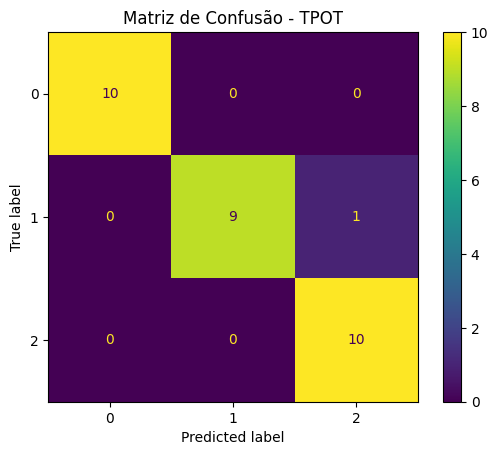

In [27]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Matriz de Confusão - TPOT")
plt.show()

### Gurdar Pipeline

In [29]:
import joblib

joblib.dump(tpot.fitted_pipeline_, "best_pipeline_tpot.pkl")

print("Pipeline guardado com sucesso.")

Pipeline guardado com sucesso.


### Ver os parâmetros principais do TPOT

In [30]:
params = tpot.get_params()

print("Parâmetros principais do TPOT:")
for chave in ["search_space", "generations", "population_size", "cv", "random_state", "n_jobs", "verbose"]:
    print(f"{chave}: {params.get(chave)}")

Parâmetros principais do TPOT:
search_space: <tpot.search_spaces.pipelines.sequential.SequentialPipeline object at 0x00000156C0554A70>
generations: None
population_size: None
cv: 10
random_state: 42
n_jobs: 1
verbose: 2


### Quantos Pipelines Foram Testados

In [31]:
if hasattr(tpot, "evaluated_individuals"):
    print("Nº de pipelines testados:", len(tpot.evaluated_individuals))
    print(tpot.evaluated_individuals)
else:
    print("Esta versão do TPOT não expõe diretamente os pipelines avaliados.")

Nº de pipelines testados: 30
    roc_auc_score   Parents          Variation_Function  \
0        0.973958       NaN                         NaN   
1             NaN       NaN                         NaN   
2             NaN       NaN                         NaN   
3        0.997917       NaN                         NaN   
4             NaN       NaN                         NaN   
5             NaN       NaN                         NaN   
6             NaN       NaN                         NaN   
7        1.000000       NaN                         NaN   
8             NaN       NaN                         NaN   
9        0.970833       NaN                         NaN   
10       0.997917    (3, 0)  ind_crossover , ind_mutate   
11       1.000000    (3, 3)                  ind_mutate   
12       1.000000    (7, 7)                  ind_mutate   
13       1.000000    (3, 3)                  ind_mutate   
14       1.000000    (7, 7)                  ind_mutate   
15       1.000000    (7, 7)

### Comparar o Pipeline do Tpot com Modelos Simples

In [40]:
modelos = {
    "TPOT Pipeline": tpot.fitted_pipeline_,
    "GaussianNB": GaussianNB(),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=200, random_state=42)
}

resultados = []

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring="f1_weighted")
    resultados.append({
        "Modelo": nome,
        "F1-score médio": scores.mean()
    })

df_resultados = pd.DataFrame(resultados).sort_values("F1-score médio", ascending=False)
df_resultados

,Modelo,F1-score médio
3,LogisticRegression,0.973165
2,RandomForest,0.966482
1,GaussianNB,0.953047
0,TPOT Pipeline,0.953047


### Gráfico Comparativo

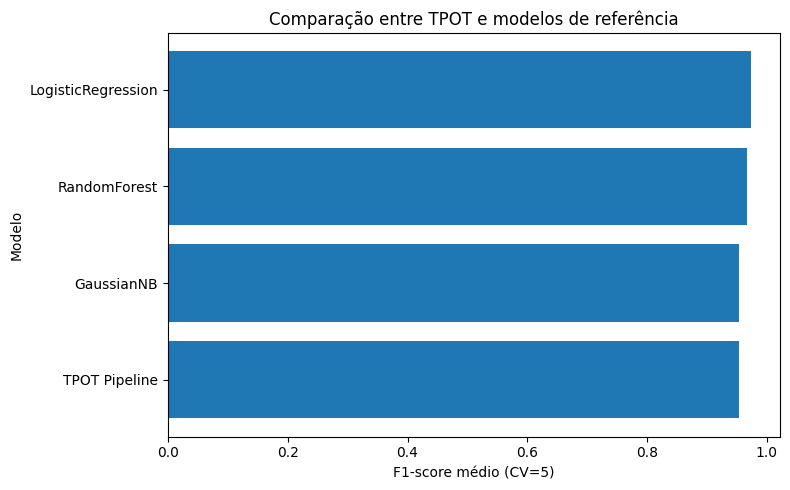

In [33]:
plt.figure(figsize=(8,5))
plt.barh(df_resultados["Modelo"], df_resultados["F1-score médio"])
plt.xlabel("F1-score médio (CV=5)")
plt.ylabel("Modelo")
plt.title("Comparação entre TPOT e modelos de referência")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Config com Ficheiro

In [41]:
import json

with open("config_tpot.json") as f:
    config = json.load(f)

In [48]:
modelos_disponiveis = {
    "sklearn.naive_bayes.GaussianNB": GaussianNB(),
    "sklearn.ensemble.RandomForestClassifier": RandomForestClassifier(random_state=42),
    "sklearn.linear_model.LogisticRegression": LogisticRegression(max_iter=200, random_state=42)
}
resultados = []

for nome in config.keys():
    modelo = modelos_disponiveis[nome]
    scores = cross_val_score(modelo, X, y, cv=5, scoring="f1_weighted")
    resultados.append({
        "Modelo": nome,
        "F1-score médio": scores.mean()
    })

df_resultados = pd.DataFrame(resultados).sort_values("F1-score médio", ascending=False)
df_resultados

,Modelo,F1-score médio
2,sklearn.linear_model.LogisticRegression,0.973165
1,sklearn.ensemble.RandomForestClassifier,0.966482
0,sklearn.naive_bayes.GaussianNB,0.953047


Foi criado um ficheiro JSON com três modelos específicos para estruturar a comparação experimental. Contudo, verificou-se que a versão do TPOT utilizada não suporta a passagem direta desse ficheiro através de config_dict. Assim, o ficheiro foi usado como referência externa para selecionar os modelos comparados manualmente, mantendo-se o TPOT apenas como ferramenta de geração automática do pipeline final.

# TPOT

O TPOT permitiu automatizar a construção do pipeline de classificação, explorando diferentes combinações de pré-processamento e modelos através de um processo evolutivo. O pipeline final selecionado apresentou desempenho elevado no dataset Iris, confirmando a eficácia da ferramenta em problemas simples e bem estruturados.

A análise do pipeline mostra, no entanto, que a solução final convergiu para um modelo relativamente simples, o que sugere que a complexidade adicional explorada pelo TPOT não trouxe ganhos significativos neste caso. Esta conclusão está de acordo com a análise exploratória, que já indicava elevada separabilidade entre classes e forte poder discriminativo das variáveis associadas às pétalas.

Assim, o principal contributo do TPOT neste contexto não reside apenas no desempenho obtido, mas na capacidade de automatizar a procura de soluções e de gerar um pipeline final interpretável e exportável.